# Tweeting Fear: Unsupervised Learning
### BUSN 20800 Big Data
**Hewitt Watkins · Erik Lopez · Mateo Fretes · Vedant Dangayach**

Inputs: `master_weekly.csv`, `tweet_embeddings.npy`, `tweet_embeddings_index.csv`

Outputs: `tweet_labels.csv` (GPT-2 training data), topic/cluster plots

## 0. Install & Import

In [1]:
!pip install gensim nltk -q
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
print('Done')

Done


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings, re
warnings.filterwarnings('ignore')

from nltk.corpus import stopwords
from gensim import corpora
from gensim.models import LdaMulticore
from gensim.models.coherencemodel import CoherenceModel
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, adjusted_mutual_info_score

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 130, 'axes.titlesize': 12, 'axes.labelsize': 10})

K_RANGE = [4, 6, 8, 10, 12]   # candidate K for both LDA and K-means
print('Imports OK')

Imports OK


## 1. Load Data

In [3]:
# Master weekly dataset
master = pd.read_csv('master_weekly.csv')
master['week_end'] = pd.to_datetime(master['week_end'])
print(f'Master: {master.shape}  |  {master["week_end"].min().date()} → {master["week_end"].max().date()}')

# FinBERT per-tweet embeddings
embeddings  = np.load('tweet_embeddings.npy')
embed_index = pd.read_csv('tweet_embeddings_index.csv')
embed_index['date'] = pd.to_datetime(embed_index['date'], utc=True, errors='coerce')
print(f'Embeddings: {embeddings.shape}')
print(f'Embed index: {len(embed_index):,} rows')
print(embed_index.head(3).to_string())

Master: (403, 27)  |  2017-01-20 → 2026-01-09
Embeddings: (41502, 768)
Embed index: 41,502 rows
   tweet_idx                      date                                                                                                                                                              text
0          0 2017-01-20 00:40:51+00:00  Thank you for joining us at the Lincoln Memorial tonight- a very special evening! Together, we are going to MAKE AMERICA GREAT AGAIN! pic.twitter.com/5d774OCx5o
1          1 2017-01-20 04:24:33+00:00                                                                    Thank you for a wonderful evening in Washington, D.C. #Inauguration pic.twitter.com/a6xpFQTHj5
2          2 2017-01-20 12:31:53+00:00                                                  It all begins today! I will see you at 11:00 A.M. for the swearing-in. THE MOVEMENT CONTINUES - THE WORK BEGINS!


## 2. LDA Topic Modeling

Fit on all tweets. K selected by c_v coherence score over K ∈ {4, 6, 8, 10, 12}.

In [4]:
STOP = set(stopwords.words('english'))
STOP.update(['https', 'http', 'rt', 'amp', 'co', 'via', 'pic',
             'twitter', 'realdonaldtrump', 'trump', 'president'])

def preprocess(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#(\w+)', r'\1', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return [t for t in text.split() if t not in STOP and len(t) > 2]

print('Preprocessing tweet texts...')
tokenized = [preprocess(t) for t in embed_index['text']]
print(f'Done. Example: {tokenized[0][:8]}')

Preprocessing tweet texts...
Done. Example: ['thank', 'joining', 'lincoln', 'memorial', 'tonight', 'special', 'evening', 'together']


In [5]:
dictionary = corpora.Dictionary(tokenized)
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(t) for t in tokenized]
print(f'Dictionary: {len(dictionary):,} terms')
print(f'Corpus:     {len(corpus):,} documents')

Dictionary: 8,414 terms
Corpus:     41,502 documents


Fitting LDA models over K = [4, 6, 8, 10, 12]
  K= 4: c_v coherence = 0.7654
  K= 6: c_v coherence = 0.7384
  K= 8: c_v coherence = 0.7075
  K=10: c_v coherence = 0.7317
  K=12: c_v coherence = 0.6533


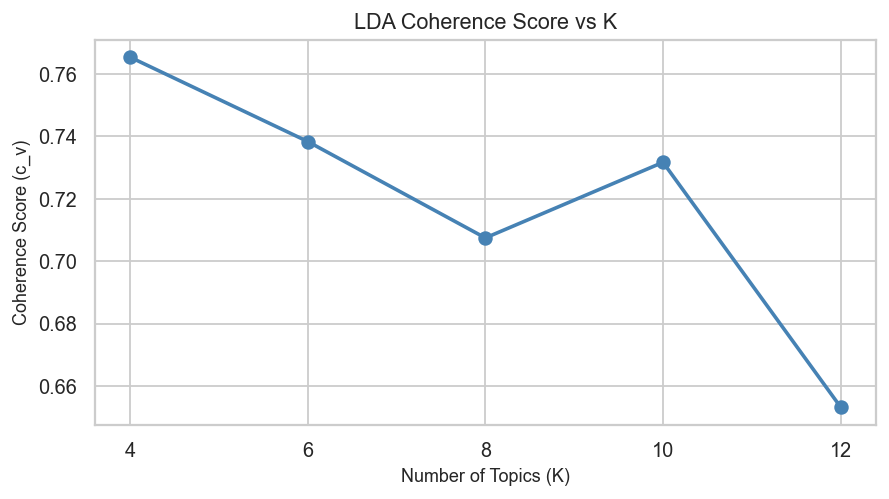


Best K by coherence: 4  (score=0.7654)
Override CHOSEN_K_LDA below if a lower K is more interpretable.


In [6]:
lda_models       = {}
coherence_scores = {}

print('Fitting LDA models over K =', K_RANGE)
for k in K_RANGE:
    lda = LdaMulticore(corpus, num_topics=k, id2word=dictionary,
                       passes=15, workers=2, random_state=42)
    cm  = CoherenceModel(model=lda, texts=tokenized,
                         dictionary=dictionary, coherence='c_v')
    score = cm.get_coherence()
    lda_models[k]       = lda
    coherence_scores[k] = score
    print(f'  K={k:2d}: c_v coherence = {score:.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_RANGE, [coherence_scores[k] for k in K_RANGE],
        'o-', color='steelblue', lw=2, ms=7)
ax.set_xlabel('Number of Topics (K)')
ax.set_ylabel('Coherence Score (c_v)')
ax.set_title('LDA Coherence Score vs K')
ax.set_xticks(K_RANGE)
plt.tight_layout()
plt.savefig('lda_coherence.png', dpi=150, bbox_inches='tight')
plt.show()

best_k_lda  = max(coherence_scores, key=coherence_scores.get)
print(f'\nBest K by coherence: {best_k_lda}  (score={coherence_scores[best_k_lda]:.4f})')
print('Override CHOSEN_K_LDA below if a lower K is more interpretable.')
CHOSEN_K_LDA = best_k_lda

In [7]:
lda_final = lda_models[CHOSEN_K_LDA]

print(f'Top 12 words per topic  (K={CHOSEN_K_LDA})')
print('='*65)
for idx, topic in lda_final.print_topics(num_words=12):
    print(f'Topic {idx}: {topic}')
    print()

Top 12 words per topic  (K=4)
Topic 0: 0.021*"great" + 0.013*"america" + 0.010*"country" + 0.010*"make" + 0.008*"states" + 0.008*"united" + 0.007*"thank" + 0.007*"big" + 0.006*"vote" + 0.006*"people" + 0.006*"get" + 0.006*"world"

Topic 1: 0.008*"case" + 0.008*"election" + 0.007*"judge" + 0.007*"never" + 0.006*"country" + 0.006*"new" + 0.006*"york" + 0.005*"would" + 0.005*"court" + 0.005*"political" + 0.005*"russia" + 0.005*"people"

Topic 2: 0.023*"great" + 0.014*"total" + 0.014*"complete" + 0.014*"endorsement" + 0.013*"secure" + 0.012*"border" + 0.012*"second" + 0.011*"thank" + 0.010*"support" + 0.010*"always" + 0.010*"american" + 0.009*"first"

Topic 3: 0.034*"image" + 0.021*"video" + 0.013*"news" + 0.013*"biden" + 0.013*"fake" + 0.012*"joe" + 0.008*"like" + 0.007*"election" + 0.007*"people" + 0.006*"even" + 0.006*"never" + 0.006*"crooked"



In [8]:
print('Assigning dominant topic to each tweet...')
embed_index['lda_topic'] = [
    max(lda_final.get_document_topics(corpus[i], minimum_probability=0),
        key=lambda x: x[1])[0]
    for i in range(len(corpus))
]
print('Topic distribution:')
print(embed_index['lda_topic'].value_counts().sort_index().to_string())

Assigning dominant topic to each tweet...
Topic distribution:
lda_topic
0    16612
1     7875
2     4647
3    12368


## 3. PCA + K-means on FinBERT Embeddings

Reduce 768-dim embeddings to 50 dims via PCA, then cluster with K-means. K selected by silhouette score over K ∈ {4, 6, 8, 10, 12}.

In [9]:
print('Standardising and reducing embeddings (768 → 50 dims)...')
scaler = StandardScaler()
E_scaled = scaler.fit_transform(embeddings)
pca_50 = PCA(n_components=50, random_state=42)
E_50   = pca_50.fit_transform(E_scaled)
print(f'Variance explained by 50 PCs: {pca_50.explained_variance_ratio_.sum():.1%}')
print(f'Reduced shape: {E_50.shape}')

Standardising and reducing embeddings (768 → 50 dims)...
Variance explained by 50 PCs: 81.2%
Reduced shape: (41502, 50)


Fitting K-means models over K = [4, 6, 8, 10, 12]
  K= 4: inertia=14,626,638  silhouette=0.2524
  K= 6: inertia=12,885,728  silhouette=0.2324
  K= 8: inertia=11,918,478  silhouette=0.2034
  K=10: inertia=11,294,904  silhouette=0.2015
  K=12: inertia=10,854,008  silhouette=0.1929


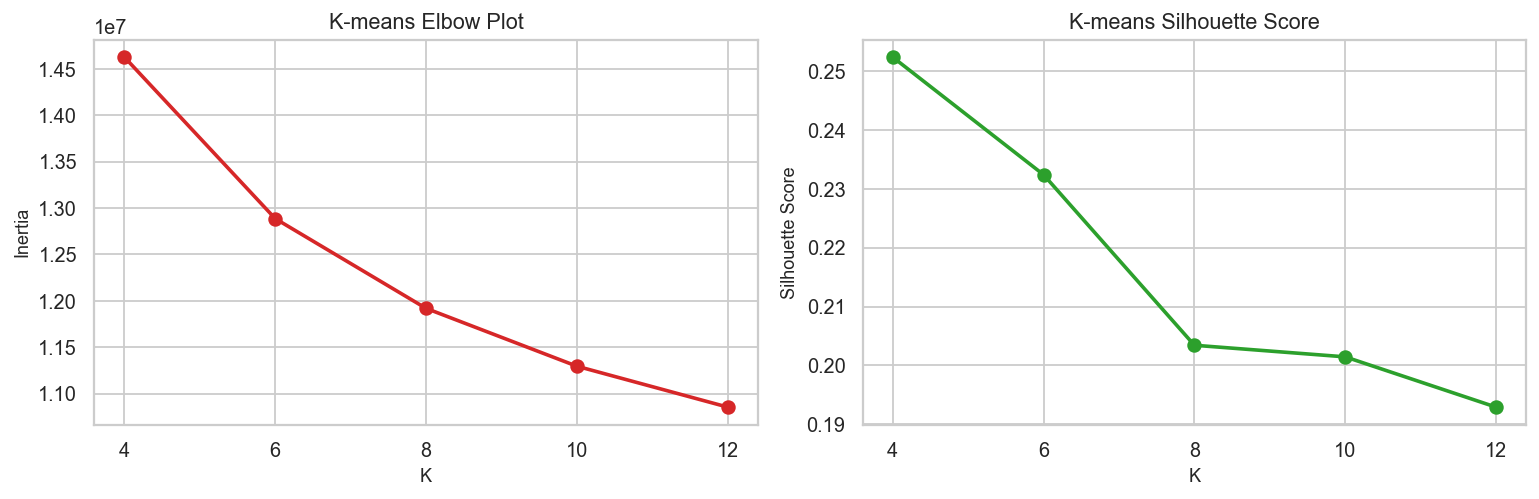


Best K by silhouette: 4  (score=0.2524)
Override CHOSEN_K_KM below if needed.


In [10]:
inertias    = {}
sil_scores  = {}
km_models   = {}

print('Fitting K-means models over K =', K_RANGE)
for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(E_50)
    sil    = silhouette_score(E_50, labels, sample_size=5000, random_state=42)
    inertias[k]   = km.inertia_
    sil_scores[k] = sil
    km_models[k]  = km
    print(f'  K={k:2d}: inertia={km.inertia_:,.0f}  silhouette={sil:.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(K_RANGE, [inertias[k]   for k in K_RANGE], 'o-', color='#d62728', lw=2, ms=7)
ax1.set_xlabel('K')  ;  ax1.set_ylabel('Inertia')
ax1.set_title('K-means Elbow Plot')  ;  ax1.set_xticks(K_RANGE)
ax2.plot(K_RANGE, [sil_scores[k] for k in K_RANGE], 'o-', color='#2ca02c', lw=2, ms=7)
ax2.set_xlabel('K')  ;  ax2.set_ylabel('Silhouette Score')
ax2.set_title('K-means Silhouette Score')  ;  ax2.set_xticks(K_RANGE)
plt.tight_layout()
plt.savefig('kmeans_selection.png', dpi=150, bbox_inches='tight')
plt.show()

best_k_km  = max(sil_scores, key=sil_scores.get)
print(f'\nBest K by silhouette: {best_k_km}  (score={sil_scores[best_k_km]:.4f})')
print('Override CHOSEN_K_KM below if needed.')
CHOSEN_K_KM = best_k_km

In [11]:
km_final = km_models[CHOSEN_K_KM]
embed_index['kmeans_cluster'] = km_final.labels_

print(f'Representative tweets per cluster (K={CHOSEN_K_KM}):')
print('='*70)
for c in range(CHOSEN_K_KM):
    mask      = km_final.labels_ == c
    centroid  = km_final.cluster_centers_[c]
    dists     = np.linalg.norm(E_50[mask] - centroid, axis=1)
    closest   = np.where(mask)[0][np.argsort(dists)[:5]]
    print(f'\nCluster {c}  ({mask.sum():,} tweets):')
    for idx in closest:
        print(f'  {str(embed_index.loc[idx, "text"])[:120]}')

Representative tweets per cluster (K=4):

Cluster 0  (11,865 tweets):
  Cryin’ Chuck Schumer said, “You will pay the price for this. You won’t know what HIT YOU.” That is far beyond simple rhe
  What the Democrats are doing is “Obstruction of the Senate. It’s wrong Constitutionally, it’s wrong morally, and it’s wr
  Look, it’s not my fault that my political opponent in the Democrat Party, Crooked Joe Biden, has told his Attorney Gener
  Robert Mueller was a God-like figure to the Democrats, until he ruled No Collusion in the long awaited $30,000,000 Muell
  Check out tweets from last two days. I refer to Fake News Media when mentioning Enemy of the People - but dishonest repo

Cluster 1  (12,183 tweets):
  https://www. foxnews.com/politics/house-gop -moves-name-us-coastal-waters-after-trump
  https://www. express.co.uk/news/us/1975695/ donald-trump-team-maga
  https://www. newsweek.com/sen-rubio-novembe r-americas-last-chance-lets-take-it-electing-donald-trump-opinion-1907049
  https:/

## 4. Compare LDA Topics vs K-means Clusters

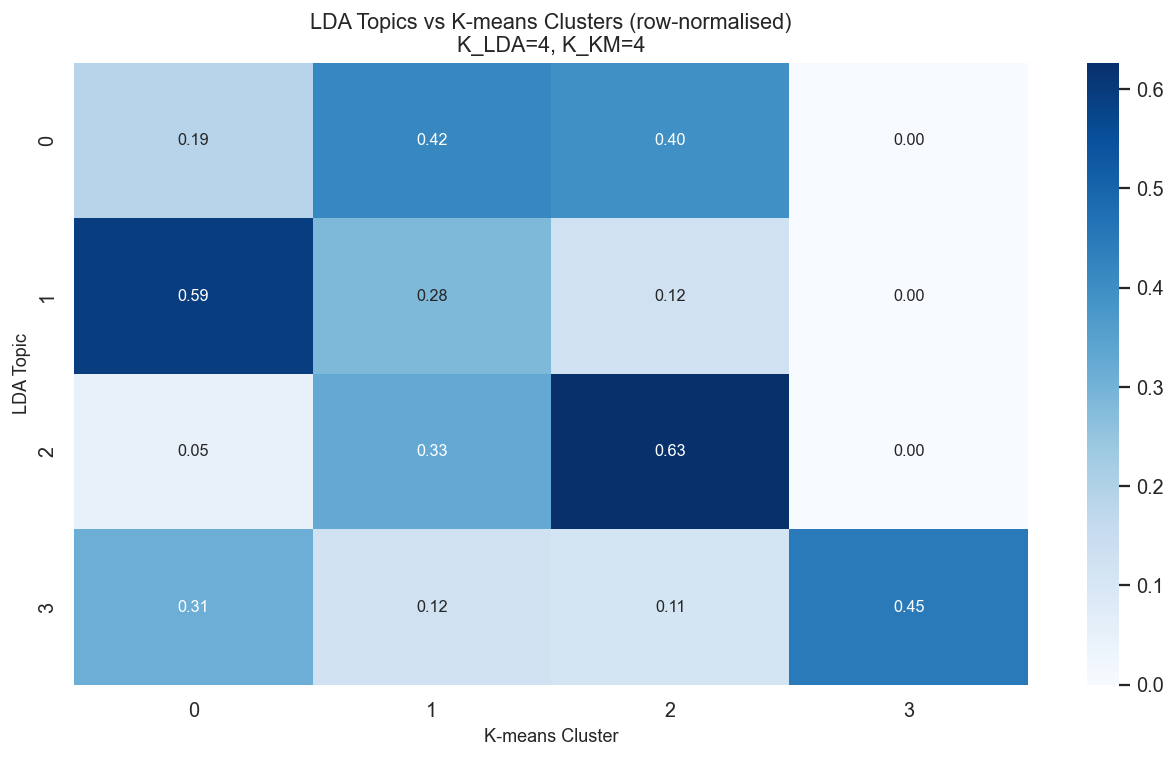

Adjusted Mutual Information (AMI): 0.2222
(1.0 = perfect agreement, 0.0 = chance)


In [12]:
ct      = pd.crosstab(embed_index['lda_topic'], embed_index['kmeans_cluster'],
                       rownames=['LDA Topic'], colnames=['K-means Cluster'])
ct_norm = ct.div(ct.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(ct_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
            annot_kws={'size': 9})
ax.set_title(f'LDA Topics vs K-means Clusters (row-normalised)\n'
             f'K_LDA={CHOSEN_K_LDA}, K_KM={CHOSEN_K_KM}')
plt.tight_layout()
plt.savefig('topic_cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

ami = adjusted_mutual_info_score(embed_index['lda_topic'], embed_index['kmeans_cluster'])
print(f'Adjusted Mutual Information (AMI): {ami:.4f}')
print('(1.0 = perfect agreement, 0.0 = chance)')

## 5. Temporal Analysis

Weekly topic proportions overlaid with VIX, plus a correlation table.

In [13]:
# Assign week_end to each tweet (same bucketing as main notebook)
embed_index['week_end'] = (
    embed_index['date']
    .dt.to_period('W-FRI')
    .apply(lambda p: p.end_time)
    .dt.tz_localize(None)
    .dt.normalize()
)
embed_index['week_end'] = pd.to_datetime(embed_index['week_end'])

# Weekly topic proportions
dummies = pd.get_dummies(embed_index['lda_topic'].astype(str), prefix='topic')
dummies['week_end'] = embed_index['week_end'].values
topic_props = dummies.groupby('week_end').mean().reset_index()
topic_cols  = [c for c in topic_props.columns if c.startswith('topic_')]

tp_vix = topic_props.merge(master[['week_end','vix']], on='week_end', how='inner')
print(f'Weekly topic proportion matrix: {tp_vix.shape}')

Weekly topic proportion matrix: (403, 6)


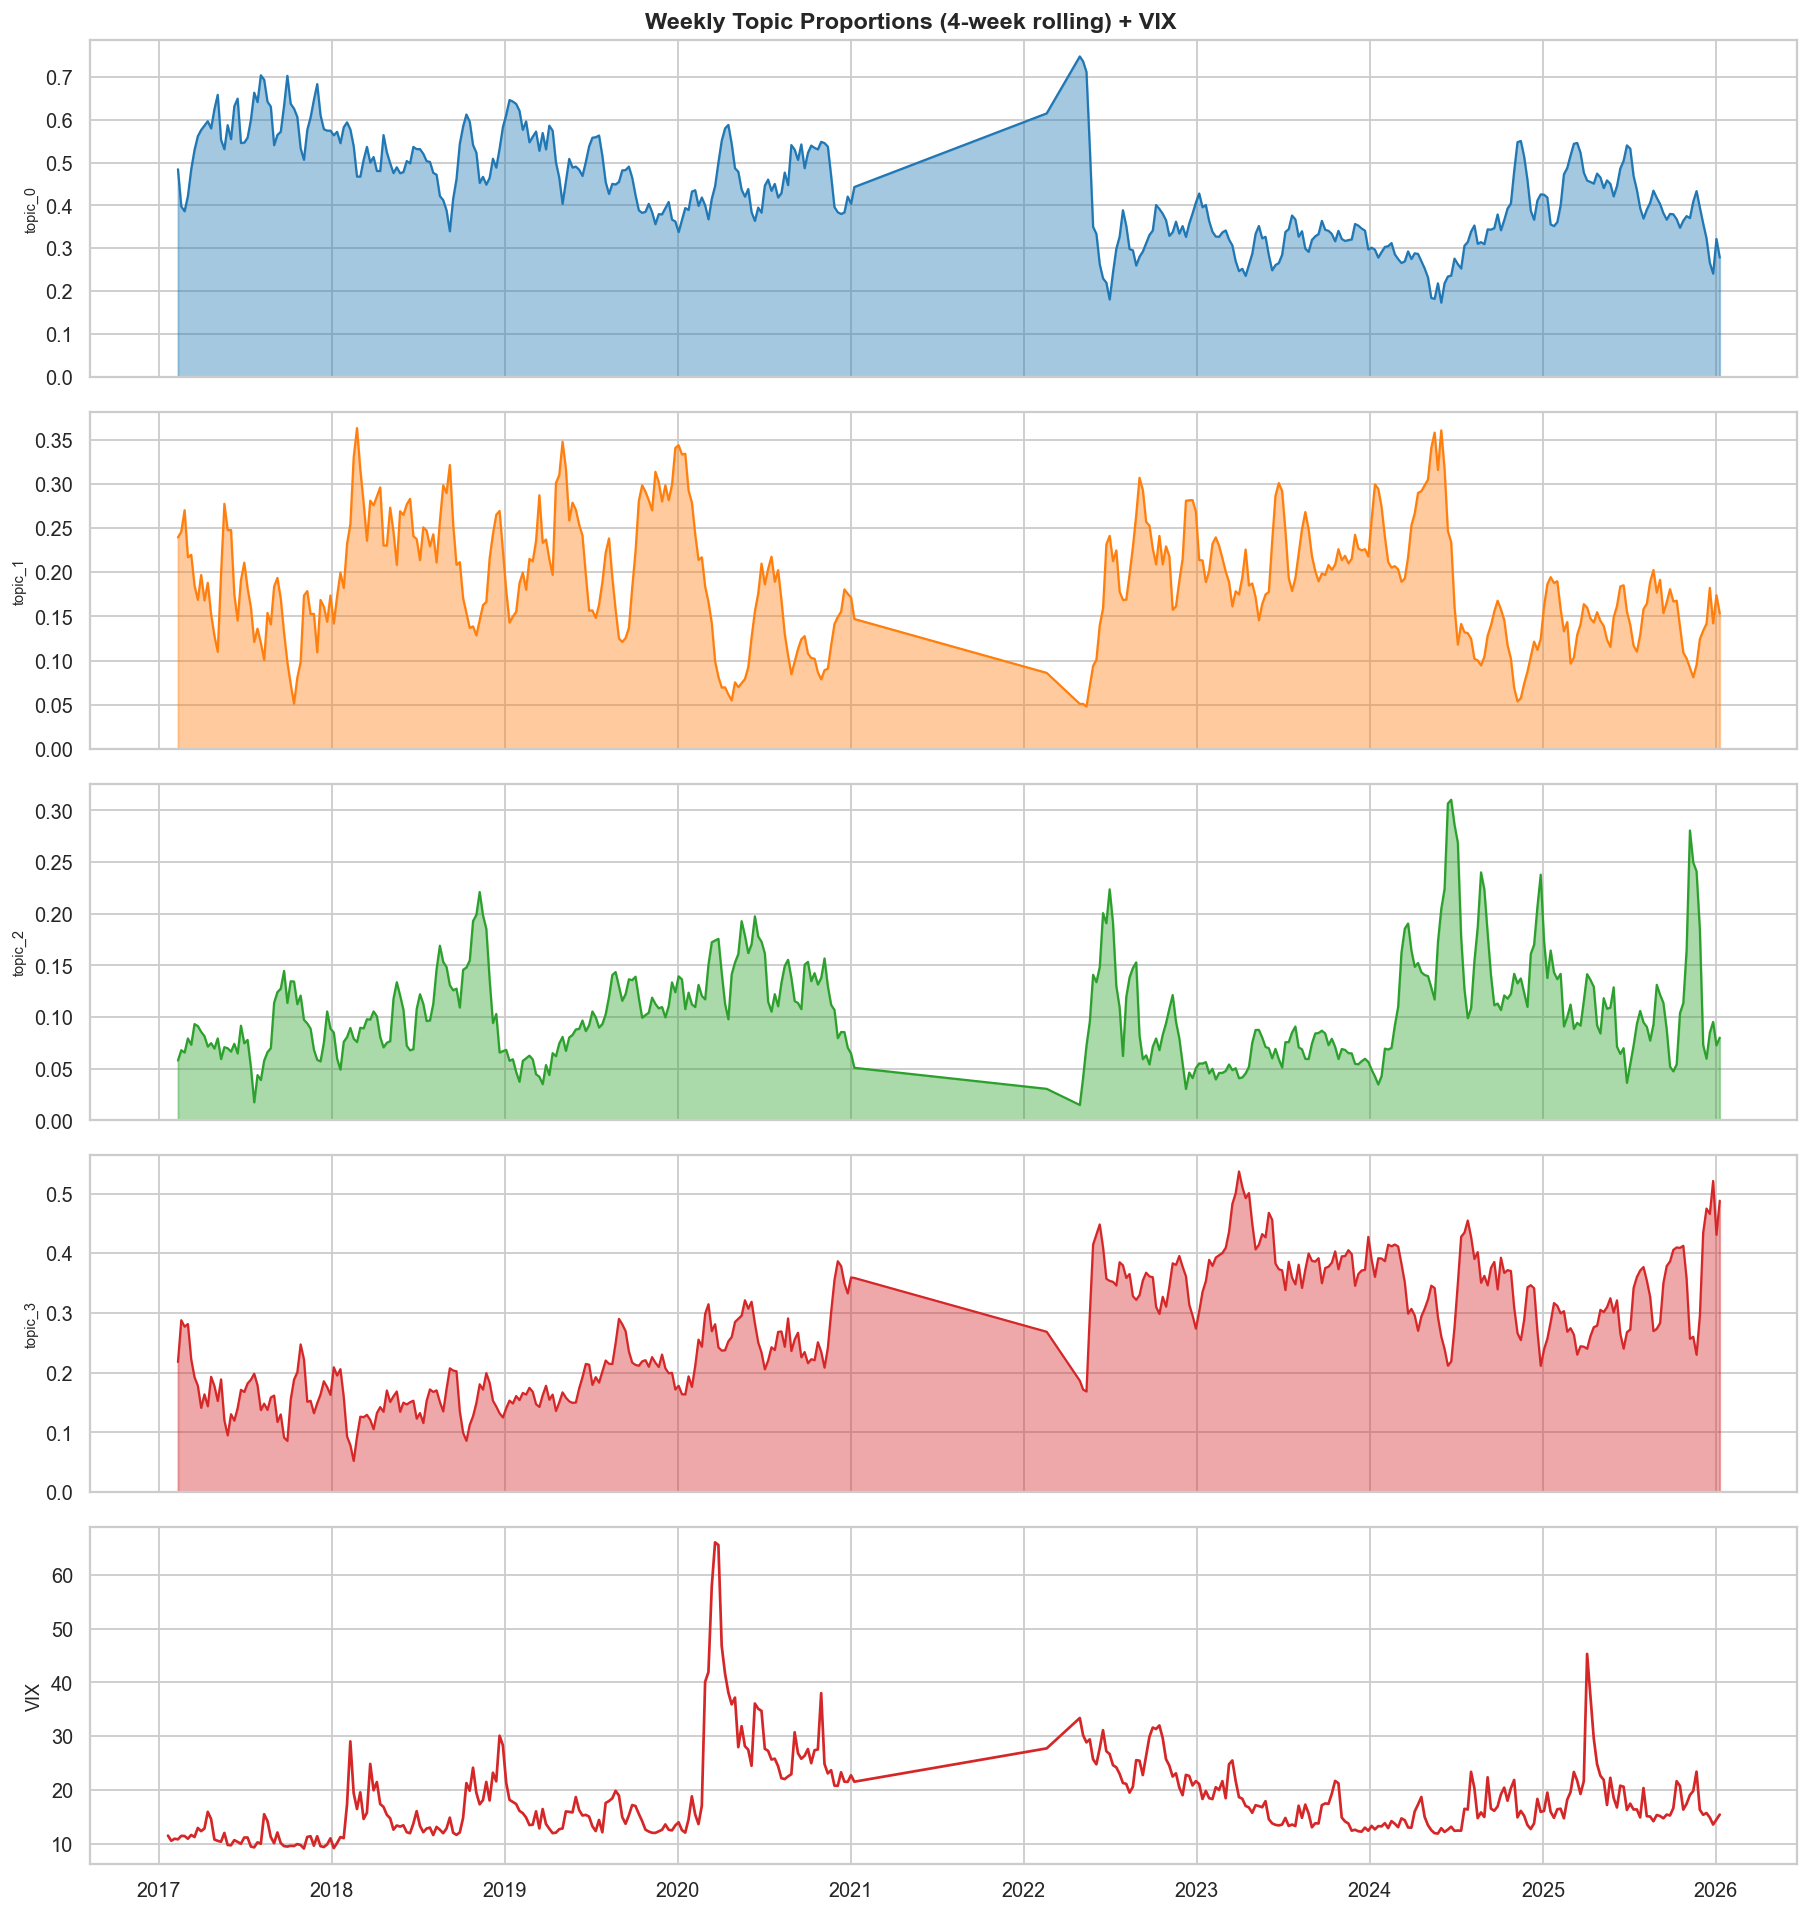

In [14]:
n = len(topic_cols)
fig, axes = plt.subplots(n + 1, 1, figsize=(14, 3 * (n + 1)), sharex=True)
colors = plt.cm.tab10.colors

for i, tc in enumerate(topic_cols):
    roll = tp_vix.set_index('week_end')[tc].rolling(4).mean()
    axes[i].fill_between(tp_vix['week_end'], roll.values, alpha=0.4, color=colors[i])
    axes[i].plot(tp_vix['week_end'], roll.values, lw=1.2, color=colors[i])
    axes[i].set_ylabel(tc, fontsize=8)
    axes[i].set_ylim(0, None)

axes[-1].plot(tp_vix['week_end'], tp_vix['vix'], color='#d62728', lw=1.5)
axes[-1].set_ylabel('VIX')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

fig.suptitle('Weekly Topic Proportions (4-week rolling) + VIX',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('topic_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

In [15]:
from scipy import stats

corr_rows = []
for tc in topic_cols:
    tmp = tp_vix[[tc, 'vix']].dropna()
    r, p = stats.pearsonr(tmp[tc], tmp['vix'])
    corr_rows.append({
        'Topic':             tc,
        'Pearson r w/ VIX':  round(r, 4),
        'p-value':           round(p, 4),
        'Significant':       '***' if p < 0.01 else ('**' if p < 0.05 else ('*' if p < 0.10 else '')),
    })

corr_table = (pd.DataFrame(corr_rows)
              .sort_values('Pearson r w/ VIX', ascending=False))
print('Topic-VIX Correlation Table')
print('='*55)
print(corr_table.to_string(index=False))

Topic-VIX Correlation Table
  Topic  Pearson r w/ VIX  p-value Significant
topic_3            0.1193   0.0166          **
topic_2            0.1181   0.0177          **
topic_0           -0.0019   0.9693            
topic_1           -0.2445   0.0000         ***


## 6. Save Labels for GPT-2

VIX and EPU discretised into 3 tertile buckets (fit on all data). One row per tweet with GPT-2 prompt string.

In [16]:
# Tertile cuts from all weeks with data
mc = master[['week_end', 'vix', 'epu']].dropna()
vix_cuts = mc['vix'].quantile([1/3, 2/3]).values
epu_cuts = mc['epu'].quantile([1/3, 2/3]).values

def vix_bucket(v):
    if   pd.isna(v):        return np.nan
    elif v <= vix_cuts[0]:  return 'VIX_LOW'
    elif v <= vix_cuts[1]:  return 'VIX_MED'
    else:                   return 'VIX_HIGH'

def epu_bucket(e):
    if   pd.isna(e):        return np.nan
    elif e <= epu_cuts[0]:  return 'EPU_LOW'
    elif e <= epu_cuts[1]:  return 'EPU_MED'
    else:                   return 'EPU_HIGH'

master['vix_bucket'] = master['vix'].apply(vix_bucket)
master['epu_bucket'] = master['epu'].apply(epu_bucket)

print(f'VIX tertile cutoffs:  {vix_cuts.round(2)}')
print(f'EPU tertile cutoffs:  {epu_cuts.round(2)}')
print()
print('VIX bucket counts:')
print(master['vix_bucket'].value_counts().to_string())
print()
print('EPU bucket counts:')
print(master['epu_bucket'].value_counts().to_string())

VIX tertile cutoffs:  [13.83 19.32]
EPU tertile cutoffs:  [119.78 163.24]

VIX bucket counts:
vix_bucket
VIX_LOW     135
VIX_HIGH    135
VIX_MED     133

EPU bucket counts:
epu_bucket
EPU_MED     135
EPU_LOW     134
EPU_HIGH    134


In [17]:
labels = embed_index[['tweet_idx','date','text','week_end',
                        'lda_topic','kmeans_cluster']].copy()

labels = labels.merge(
    master[['week_end','vix_bucket','epu_bucket','vix','epu']],
    on='week_end', how='left'
)

# GPT-2 prompt: [VIX_X] [EPU_X] [TOPIC_N] <tweet text>
labels['gpt2_prompt'] = (
    '[' + labels['vix_bucket'].fillna('VIX_UNK') + '] ' +
    '[' + labels['epu_bucket'].fillna('EPU_UNK') + '] ' +
    '[TOPIC_' + labels['lda_topic'].astype(str) + '] ' +
    labels['text'].astype(str)
)

labels_clean = labels.dropna(subset=['vix_bucket', 'epu_bucket'])
labels_clean.to_csv('tweet_labels.csv', index=False)

print(f'Labeled tweets saved:  {len(labels_clean):,}')
print(f'Dropped (gap period):  {len(labels) - len(labels_clean):,}')
print(f'Columns: {list(labels_clean.columns)}')
print()
print('Sample GPT-2 prompts:')
for row in labels_clean['gpt2_prompt'].sample(3, random_state=42):
    print(f'  {row[:120]}')

Labeled tweets saved:  41,502
Dropped (gap period):  0
Columns: ['tweet_idx', 'date', 'text', 'week_end', 'lda_topic', 'kmeans_cluster', 'vix_bucket', 'epu_bucket', 'vix', 'epu', 'gpt2_prompt']

Sample GPT-2 prompts:
  [VIX_HIGH] [EPU_HIGH] [TOPIC_0] https:// truthsocial.com/users/mazurikl /statuses/114939295209318552
  [VIX_LOW] [EPU_MED] [TOPIC_3] [Image]
  [VIX_LOW] [EPU_LOW] [TOPIC_0] Thank you to the great @JimBrownNFL32, perhaps the greatest running back of all time, for 
